In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from flax import nnx


from probjax.nn.loss_fn.denoising import build_time_dependent_denoising_loss

from probjax.nn import MLP, GaussianFourierEmbedding
from probjax.nn.nets.denoising_diffusion_model import EDM, VE, VP


In [3]:
def generate_data(key):
    # Mixture of Gaussians
    key, subkey = jax.random.split(key)
    u = jax.random.uniform(subkey)
    eps = jax.random.normal(subkey, (2,))
    x = jnp.where(u < 0.5, eps[0]-3., eps[1]+3)
    return x[None]

2024-12-02 15:52:36.264350: W external/xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.5 which is older than the PTX compiler version 12.6.77. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


[3.158]


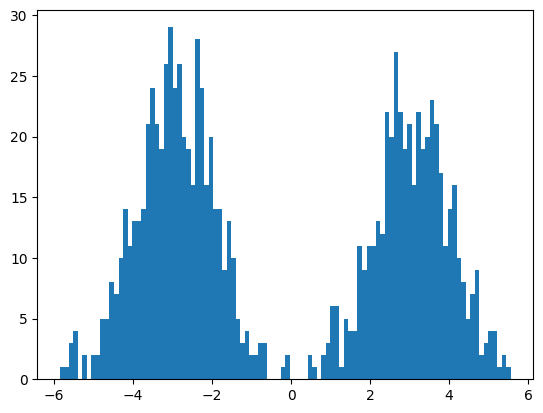

In [4]:
xs = jax.vmap(generate_data)(jax.random.split(jax.random.PRNGKey(0), 1000))
print(xs.std(0))
_ = plt.hist(xs.flatten(), bins=100)

In [5]:
d = 1
class BaseModel(nnx.Module, experimental_pytree=True):
    def __init__(self, d, rngs) -> None:
        self.time_embedding = GaussianFourierEmbedding(1,4, rngs=rngs)
        #self.time_embedding = lambda t: jnp.repeat(t, 5, axis=-1)
        self.mlp = MLP([d+4,50,50,50,d], rngs=rngs)

    def __call__(self, t,x, *args, **kwargs):
        time_embed = self.time_embedding(t)
        inp = jnp.concatenate([time_embed, x], axis=-1)
        output = self.mlp(inp)
        return output

net = BaseModel(1, nnx.Rngs(0))
model = VP(net, std0=1.)
params = nnx.state(model, nnx.Param)

In [6]:

import optax

opt = optax.chain(optax.adaptive_grad_clip(1.), optax.adam(1e-3))
opt_state = opt.init(params)
@jax.jit
def update(params, opt_state, x, rng):
    loss, grads = jax.value_and_grad(model.loss)(params, rng,x)
    updates, opt_state = opt.update(grads, opt_state, params=params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

In [7]:
key = jax.random.key(0)

In [8]:
losses = []
for i in range(200):
    l = 0.
    for j in range(10):
        key,key_data, key_loss = jax.random.split(key, 3)
        xs = jax.vmap(generate_data)(jax.random.split(key_data, 1000))
        params, opt_state, loss = update(params, opt_state, xs,key_loss)
        l += loss
    losses.append(l/10)

In [9]:
nnx.update(model, params)

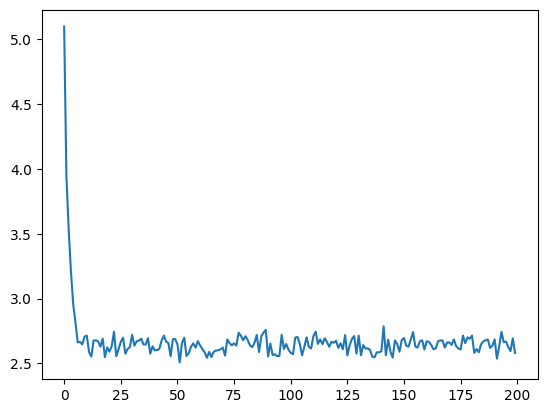

In [10]:
plt.plot(losses)

In [21]:
from probjax.utils.odeint import odeint

def sample(rng):
    eps = jax.random.normal(rng, (d,)) * model.marginal_std(model.max_noise)
    ts = model.solve_schedule()

    def drift(t, x):
        t = jnp.atleast_1d(t)
        f = model.drift(t,x)
        g = model.diffusion(t, x)
        score = model.score(t,x)
        return (f -0.5*g**2*score).reshape(x.shape)

    return odeint(drift, eps,ts, method="heun")


In [22]:
model.marginal_std(model.max_noise)

Array([1.], dtype=float32, weak_type=True)

(array([ 4.,  2.,  5.,  5.,  5.,  8., 11.,  8., 13., 10., 11., 17., 11.,
        17., 13.,  9., 17., 17., 18., 18., 18., 14., 11., 16., 14., 16.,
        19., 16.,  9., 12., 18., 15., 21., 13., 16., 15., 14., 16., 17.,
        20., 10.,  8.,  9.,  8., 11., 20., 15., 16., 12., 11., 14., 14.,
        16.,  9., 14.,  7., 10.,  9., 14., 19., 10., 16.,  9.,  9.,  5.,
         7.,  5.,  8.,  5.,  5., 13.,  6., 13.,  5.,  6.,  9., 10.,  6.,
         4.,  4.,  7.,  6.,  5.,  3.,  8.,  8.,  4.,  2.,  4.,  3.,  1.,
         1.,  2.,  3.,  4.,  0.,  4.,  3.,  0.,  2.]),
 array([0.008, 0.018, 0.027, 0.037, 0.046, 0.056, 0.066, 0.075, 0.085,
        0.094, 0.104, 0.113, 0.123, 0.132, 0.142, 0.152, 0.161, 0.171,
        0.18 , 0.19 , 0.199, 0.209, 0.218, 0.228, 0.237, 0.247, 0.257,
        0.266, 0.276, 0.285, 0.295, 0.304, 0.314, 0.323, 0.333, 0.343,
        0.352, 0.362, 0.371, 0.381, 0.39 , 0.4  , 0.409, 0.419, 0.428,
        0.438, 0.448, 0.457, 0.467, 0.476, 0.486, 0.495, 0.505, 0.514,
        

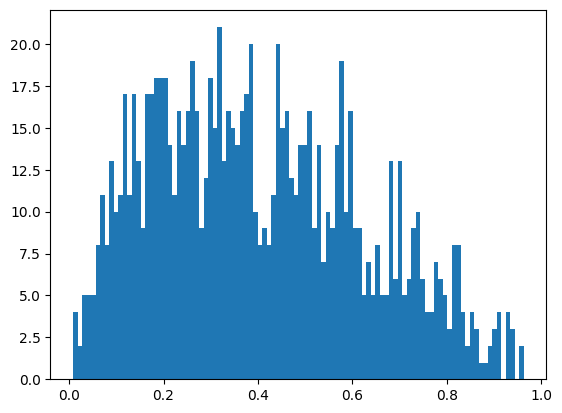

In [29]:
model.lognoise_mean = -0.5
plt.hist(model.noise_schedule(jax.random.key(0), (1000,)).flatten(), bins=100)

In [23]:
keys = jax.random.split(key, (10_000,))
xs = jax.vmap(sample)(keys)

(-10.0, 10.0)

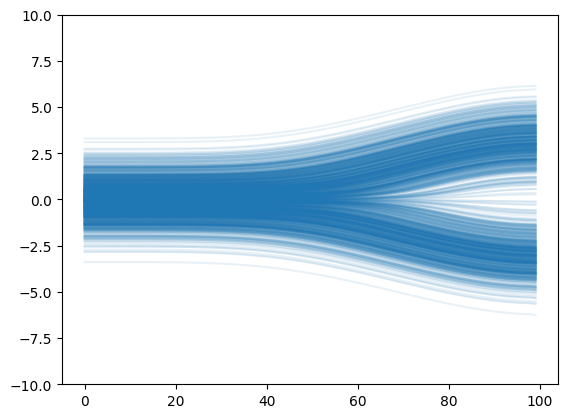

In [24]:
_ = plt.plot(xs[::10,:,0].T, color="C0", alpha=0.1)
plt.ylim(-10,10)

(-7.0, 7.0)

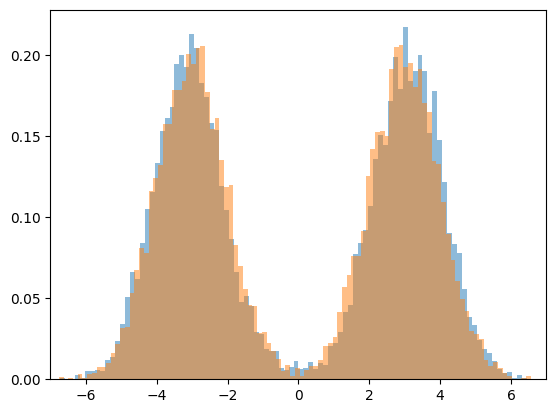

In [25]:
_ = plt.hist(xs[:,-1].flatten(), bins=100, density=True, range=(-7,7), alpha=0.5)
_ = plt.hist(jax.vmap(generate_data)(jax.random.split(jax.random.PRNGKey(0), 10000)).flatten(), bins=100, density=True, alpha=0.5)

plt.xlim(-7,7)

In [218]:
from probjax.utils.sdeint import sdeint

def sample(rng):
    rng_init, rng_sample = jax.random.split(rng)
    eps = jax.random.normal(rng_init, (d,))  * model.marginal_std(model.max_noise)
    ts = model.solve_schedule()

    def drift(t, x):
        t = jnp.atleast_1d(t)
        f = model.drift(t,x)
        g = model.diffusion(t,x)
        score = model.score(t,x)

        drift_backward = f - g**2 * score
        return drift_backward
    
    def diffusion(t, x):
        t = jnp.atleast_1d(t)
        g = model.diffusion(t,x)
        return g
    
    return sdeint(rng_sample,drift, diffusion, eps, ts, method="euler_maruyama")
    

    
    

In [219]:
keys = jax.random.split(key, (10_000,))

In [220]:
xs = jax.vmap(sample)(keys)

(-10.0, 10.0)

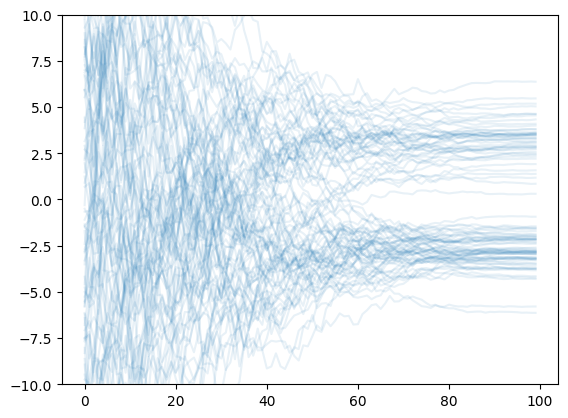

In [221]:
_ = plt.plot(xs[::100,:,0].T, color="C0", alpha=0.1)
plt.ylim(-10,10)

(-7.0, 7.0)

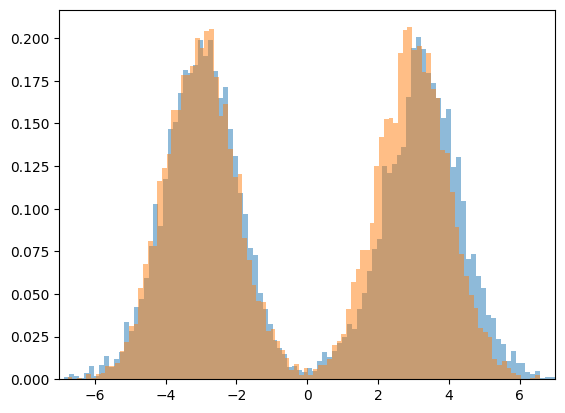

In [216]:
_ = plt.hist(xs[:,-1].flatten(), bins=100, density=True, range=(-7,7), alpha=0.5)
_ = plt.hist(jax.vmap(generate_data)(jax.random.split(jax.random.PRNGKey(0), 10000)).flatten(), bins=100, density=True, alpha=0.5)

plt.xlim(-7,7)